In this tutorial, we will load the timeseries for one patient from [Minervina et al 2021](https://elifesciences.org/articles/63502). 

The data used can be downloaded from https://zenodo.org/records/4065547 > `beta.zip > PBMC`. The example is run using `M_[]_F1_beta.txt.gz` samples. Download these samples and place them in the `test_data/input` directory.

You can also download annotated expanding and contracting clones from: https://github.com/pogorely/Minervina_COVID (Tables S3 and S5) and save them into the `examples/annotated_clones` folder.

We also generate a `metadata.txt` file with sample name and timepoint information and place it in the same directory. You can see the metadata file in `test_data/input/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from clonesearch.load_data import load_data
from clonesearch.CloneSearch import CloneSearch, CloneSearch_clustering
from clonesearch.plotting.clusters import plot_clustermap

#### 1. Load TCR sequencing data

In [2]:
# load metadata
metadata = pd.read_csv('../test_data/input/metadata.txt')
metadata

,sample,timepoint
0,M_15_F1_beta.txt.gz,15
1,M_30_F1_beta.txt.gz,30
2,M_37_F1_beta.txt.gz,37
3,M_45_F1_beta.txt.gz,45
4,M_85_F1_beta.txt.gz,85
5,M_F1_2018_beta.txt.gz,-10
6,M_F1_2019_beta.txt.gz,-5


We use CloneSearch's inbuilt loading function to prepare the data, but custom approaches can also be used.
First we have to define which columns in the file we are going to load.
We will use:
1. CDR3 column, V and J columns to define the clone - clonalSequence, bestVgene, bestJgene
2. Clone counts column - cloneCount
3. CDR3aa sequence column, to define productive sequences - aaSeqCDR3

In [3]:
columns = ['clonalSequence', 'bestVGene', 'bestJGene', 'cloneCount', 'aaSeqCDR3']
clone_id_columns = ['clonalSequence', 'bestVGene', 'bestJGene'] # which columns define the clone id

sample_order = metadata.sort_values(by = 'timepoint', ascending=True)['sample'].tolist()

tcr_data = load_data(
    input_path='../test_data/input/',
    output_path='../test_data/output/',
    delimiter='tab',
    columns=columns,
    clone_id_cols=clone_id_columns,
    sample_list=sample_order
)

All data loaded and formatted into counts per TCR.


#### 2. Run CloneSearch

CloneSearch can be run in a single command to find outliers. However, the function is fully customisable and can be run on any numpy array of counts and lists of TCRs. Thus, the user can also provide a pre-subset set of TCRs. It's important however that Nr values correspond to the original sampling depth of the samples.

In [4]:
counts = tcr_data.values
all_clones = tcr_data.index.tolist()
N_r = counts.sum(axis=0) # sequencing depth
# mapping of sample names to timepoints
timepoint_dictionary = dict(zip(metadata['sample'], metadata['timepoint']))

frequencies = pd.DataFrame(counts/N_r, index=all_clones, columns = sample_order)

In [5]:
outlier_list, pca_fit, R_thresh, freq_transformed = \
    CloneSearch(
                    counts,
                    N_r, # must be the sequencing depth of the samples
                    all_clones,
                    sample_order,
                    timepoint_dictionary,
                    statistical_threshold=0.05,
                    pval_or_fdr='fdr',
                    which_beta='constantBeta', # we recommend using this setting
                    which_QC='strictQC',
                    which_transform='g'
                )

/Users/milighm/Desktop/github-clones/CloneSearch/clonesearch/utils/gaussian_outliers.py:56: RuntimeWarning: invalid value encountered in divide
  idx = np.where((1-theory)/(1-ecdf_real.cdf.probabilities) < fdr)[0][0]


In [6]:
len(outlier_list), R_thresh

(1436, np.float64(4.889971784361453))

#### 3. Cluster the outlier sequences

In [7]:
outliers = freq_transformed.loc[outlier_list]
# normalise by the maximum
X = outliers.values
X_normed = X - X.max(axis=1).reshape(-1, 1)
outliers_norm = pd.DataFrame(X_normed,
                        index = outliers.index, columns=outliers.columns)

linkage, cluster_assignment = CloneSearch_clustering(outliers_norm, distance_thresh=0.5)
# you can play with distance_thresh to make the clusters more or less strict. 
# The higher distance_thresh, the fewer clusters you get.

In [8]:
# load known annotations for these clones

contracting = pd.read_csv('annotated_clones/Table_S3.tsv', sep = '\t')
expanding = pd.read_csv('annotated_clones/Table_S5.tsv', sep = '\t')

donor_contracting = contracting.loc[contracting['donor'] == 'M']
# make clone_id to correspond to outlier clone id
clone_id_cols = ['CDR3.nucleotide.sequence', 'bestVGene', 'bestJGene']
donor_contracting['clone_id'] = donor_contracting[clone_id_cols].astype(str).agg('::'.join, axis=1)
donor_contracting = donor_contracting['clone_id'].unique().tolist()

donor_expanding = expanding.loc[expanding['donor'] == 'M']
donor_expanding['clone_id'] = donor_expanding[clone_id_cols].astype(str).agg('::'.join, axis=1)
donor_expanding = donor_expanding['clone_id'].unique().tolist()

In [9]:
row_annotations = pd.DataFrame(index = outliers.index.tolist()) 
row_annotations['cluster_assignment'] = cluster_assignment

row_annotations['contracting'] = [c in donor_contracting for c in row_annotations.index]
row_annotations['expanding'] = [c in donor_expanding for c in row_annotations.index]

# then we need to provide columns for the annotations
annot_colors = {
    'contracting':{True:'b', False:'w'},
    'expanding':{True:'r', False:'w'}
}

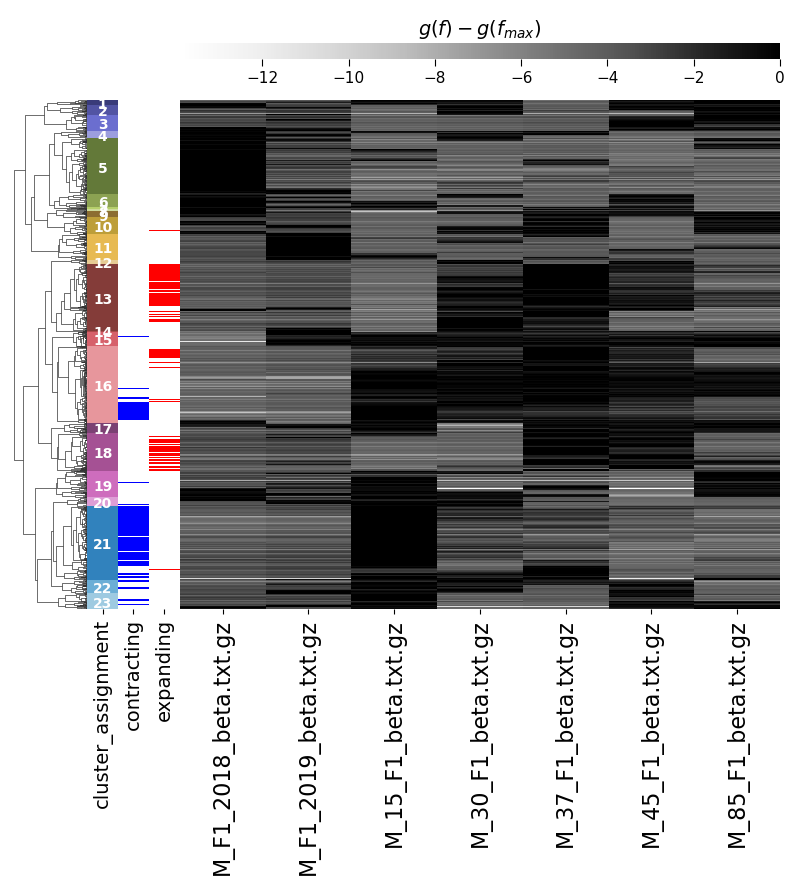

In [10]:
plot_clustermap(outliers_norm, 
                linkage, 
                row_annotations,
                annot_colors,
                cluster_col = 'cluster_assignment')
plt.show()

To understand the results, we can plot each cluster on a time series

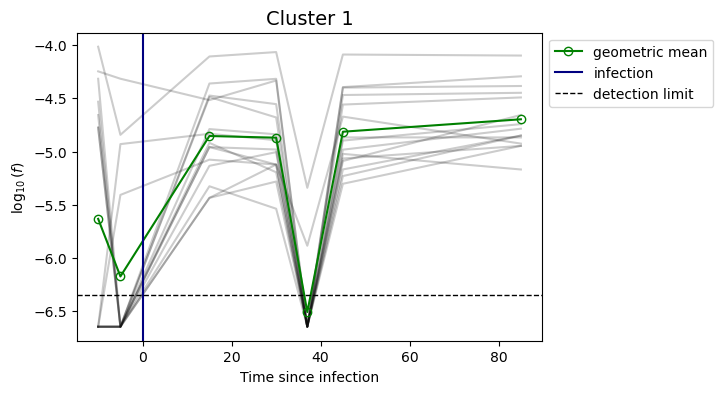

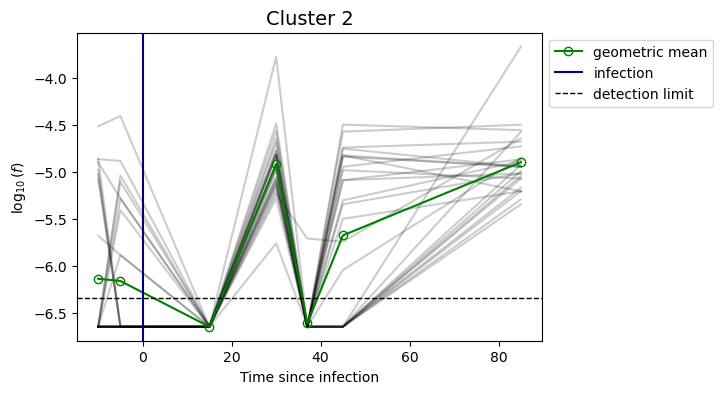

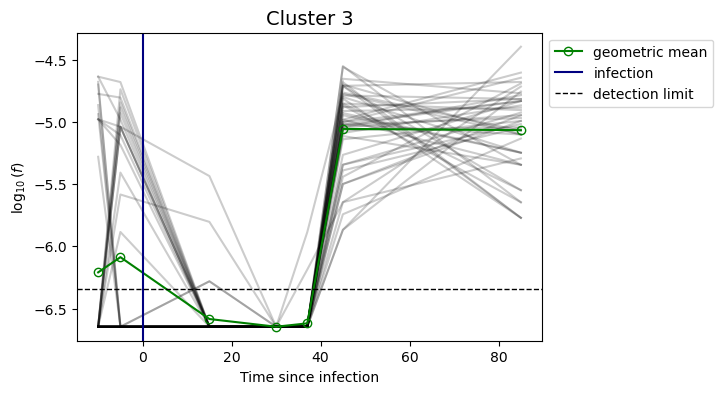

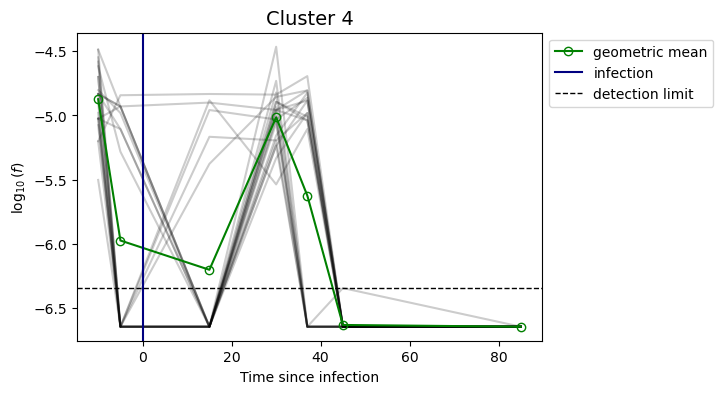

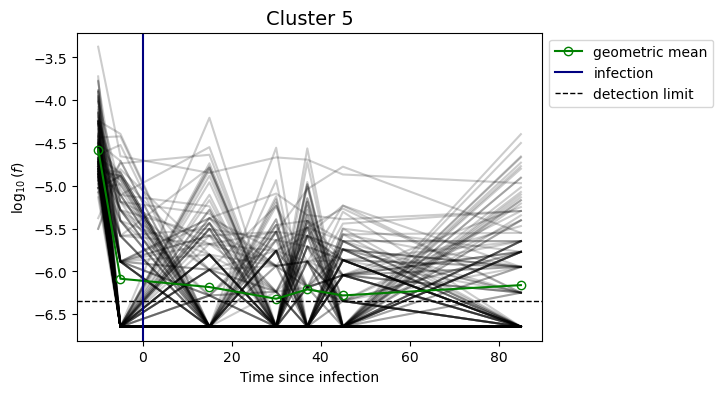

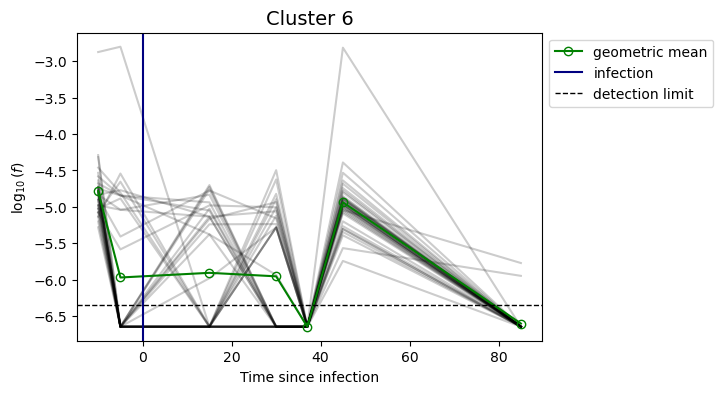

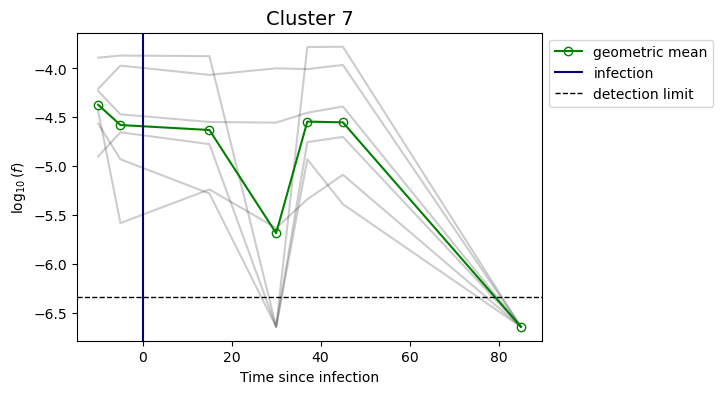

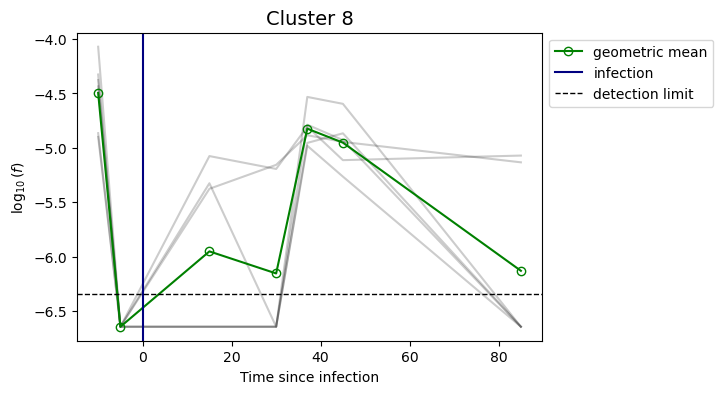

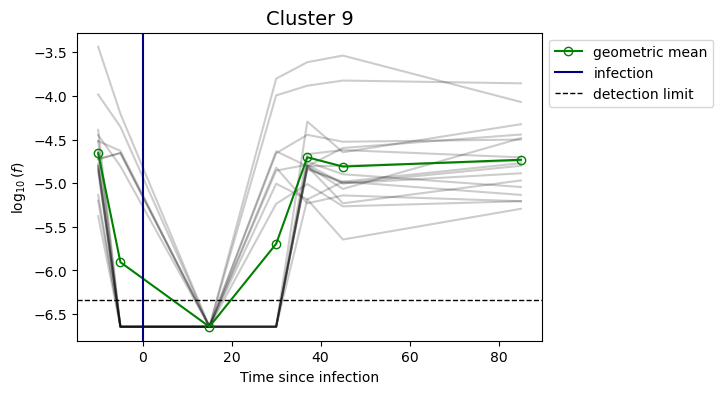

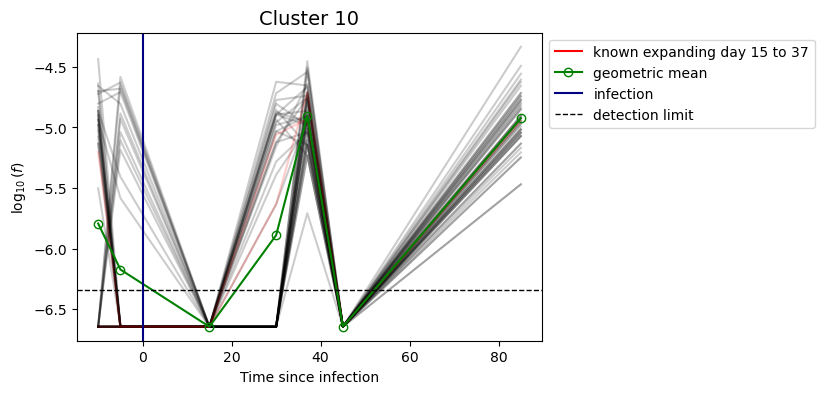

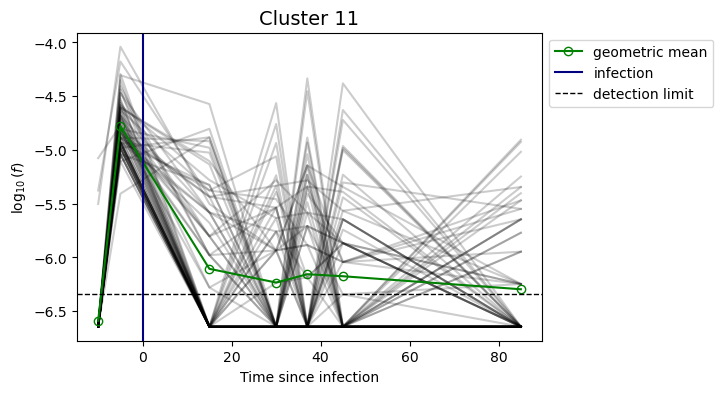

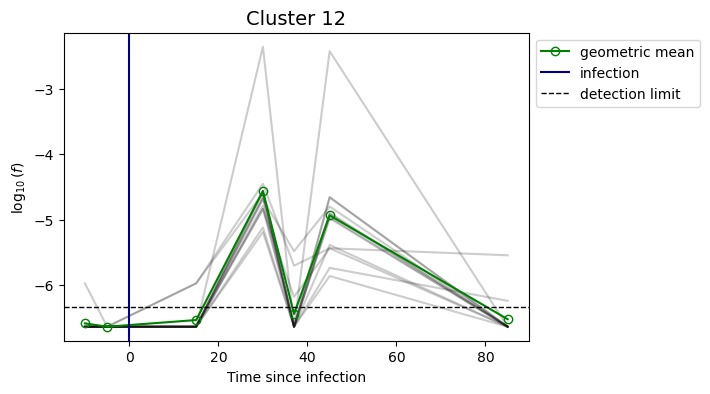

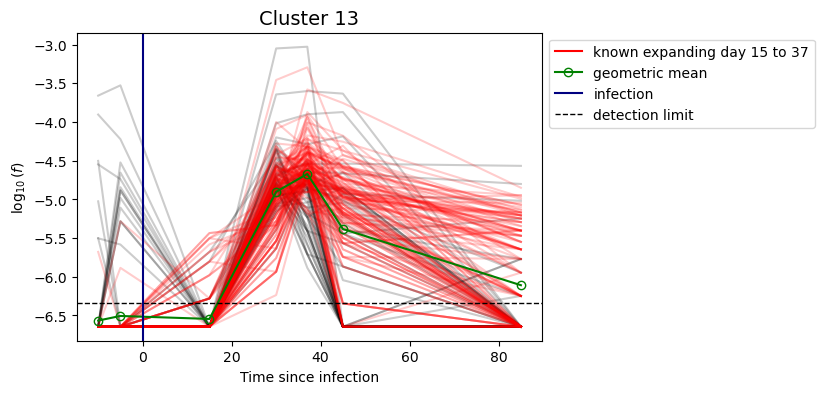

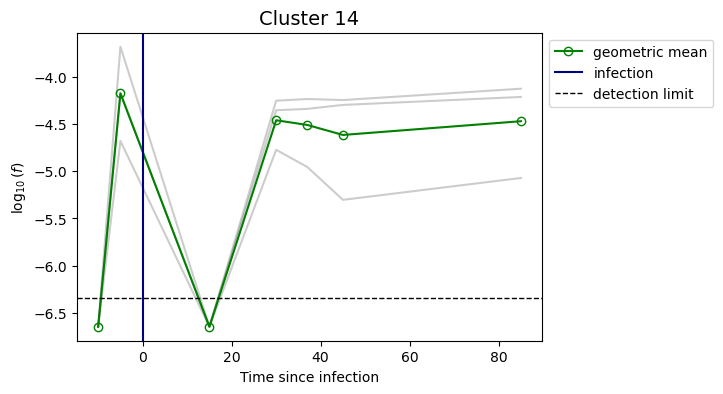

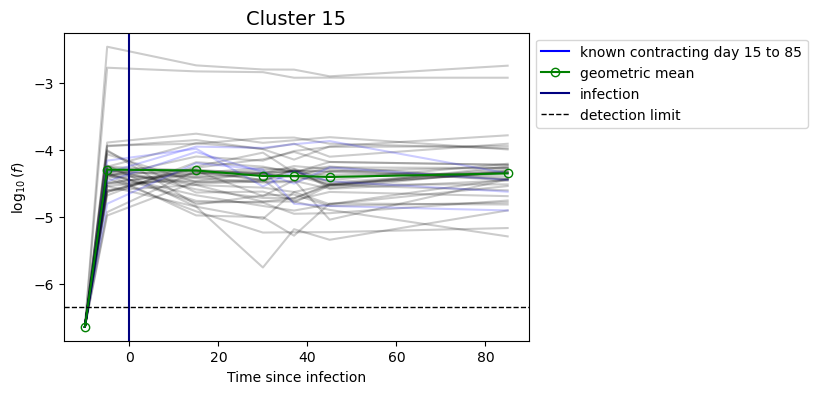

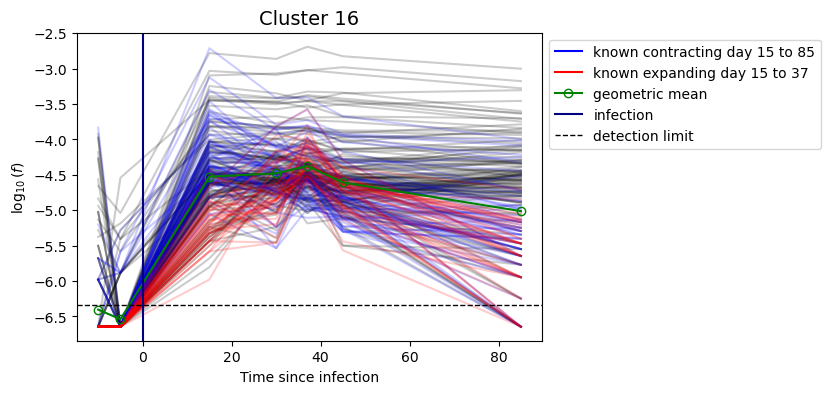

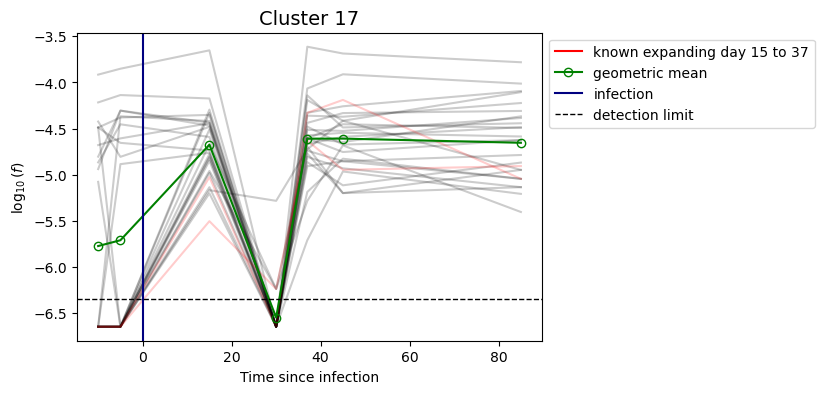

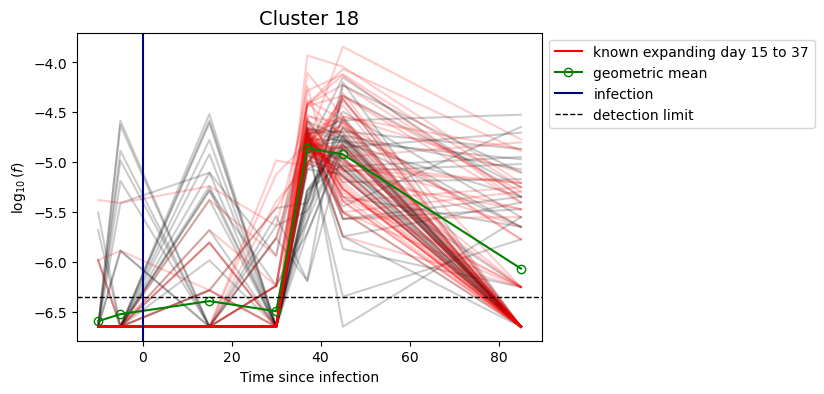

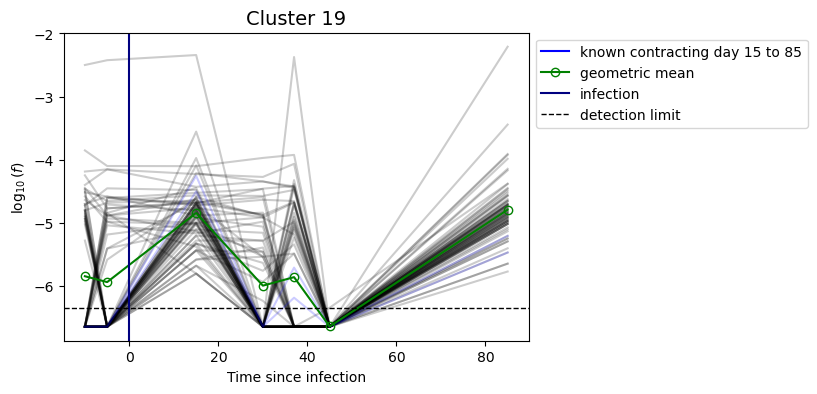

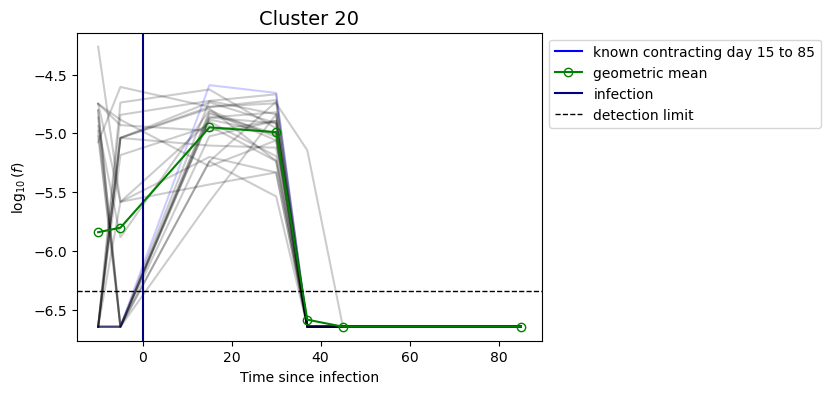

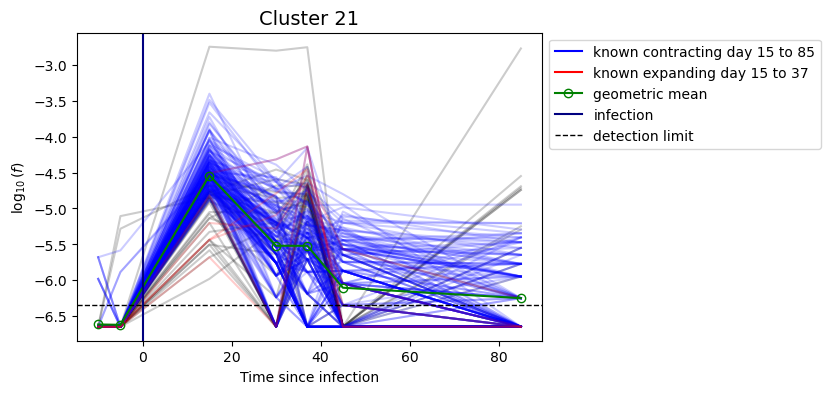

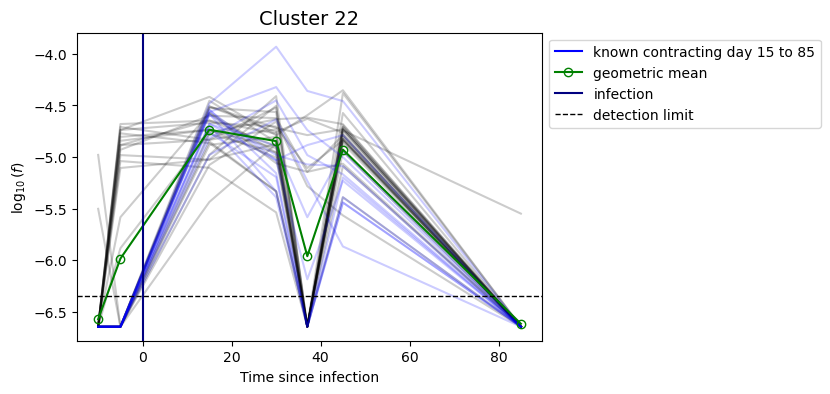

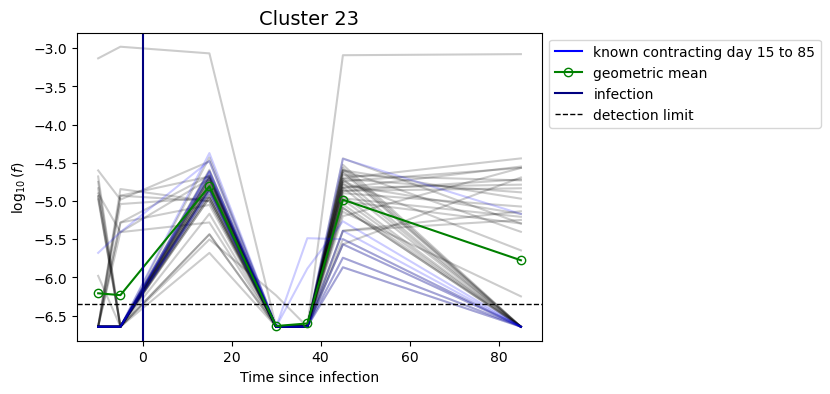

In [11]:
from scipy.stats import gmean

for c in sorted(list(set(cluster_assignment))):

    mask = cluster_assignment == c
    cluster_sequences = np.array(outlier_list)[mask]

    cluster_freqs = np.log10(frequencies.loc[cluster_sequences].replace(0, 1/(2*N_r.max())))
    cluster_freqs = cluster_freqs.rename(columns=timepoint_dictionary)

    cluster_sum = np.log10(frequencies.loc[cluster_sequences].sum(axis=0).replace(0, 1/(2*N_r.max())))
    cluster_sum = pd.DataFrame(cluster_sum).T.rename(columns=timepoint_dictionary)

    cluster_mean = cluster_freqs.mean(axis=0)

    f, axs = plt.subplots(ncols=1, figsize = (6,4))

    contr = cluster_freqs.loc[cluster_freqs.index.isin(donor_contracting)]
    expand = cluster_freqs.loc[cluster_freqs.index.isin(donor_expanding)]
    others = cluster_freqs.loc[~cluster_freqs.index.isin(donor_expanding)]
    others = others.loc[~others.index.isin(donor_contracting)]

    axs.plot(others.T, c = 'k', alpha=0.2)
    axs.plot(contr.T, c = 'b', alpha=0.2, label = 'known contracting day 15 to 85')
    axs.plot(expand.T, c = 'r', alpha=0.2, label = 'known expanding day 15 to 37')


    axs.plot(cluster_mean.T, c = 'g', 
             marker = 'o', markerfacecolor = 'none',
             label = 'geometric mean')
    axs.axvline(0, c = 'navy', label = 'infection')
    axs.axhline(np.log10(1/N_r.max()), 
                ls = '--', c = 'k', lw = 1,
                label = 'detection limit')
    
    axs.set_xlabel('Time since infection')
    axs.set_ylabel(r'$\log_{10}(f)$')

    import copy

    handles, labels = axs.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    legend_handles = {k: copy.copy(v) for k, v in by_label.items()}
    for handle in legend_handles.values():
        handle.set_alpha(1)
    axs.legend(legend_handles.values(), legend_handles.keys(),
               bbox_to_anchor = [1, 1], loc = 'upper left')
    plt.title(f'Cluster {c}', fontsize = 14)
    # plt.tight_layout()
    plt.show()